In [ ]:
import pandas as pd

df=pd.read_csv('/content/data.csv')
test_df=pd.read_csv('/content/test.csv')

df.head(3)

,index,kitchen_area,bath_area,other_area,gas,hot_water,central_heating,extra_area,extra_area_count,year,ceil_height,floor_max,floor,total_area,bath_count,extra_area_type_name,district_name,rooms_count,price
0,0,9,18,15.757559,No,No,Yes,17,1,1957,3.12,3,3,48.424226,2,balcony,Vyborgskij,0,9652263
1,1,11,22,19.919845,Yes,No,Yes,6,1,1906,2.50,2,1,54.919845,2,balcony,Vyborgskij,1,11017818
2,2,24,24,11.165478,Yes,Yes,Yes,6,1,1958,3.11,4,3,61.165478,2,loggia,Vyborgskij,1,13018374


In [ ]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

print(f'train_df: {train_df.shape}')
print(f'val_df: {val_df.shape}')
print(f'test_df: {test_df.shape}')

train_df: (80000, 19)
val_df: (20000, 19)
test_df: (100000, 18)


In [ ]:
print(f'пропусков в train_df: {df.isnull().sum().sum().item()}')
print(f'пропусков в val_df: {df.isnull().sum().sum().item()}')
print(f'пропусков в test_df: {test_df.isnull().sum().sum().item()}')

пропусков в train_df: 0
пропусков в val_df: 0
пропусков в test_df: 0


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 80000 entries, 75220 to 15795
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   index                 80000 non-null  int64  
 1   kitchen_area          80000 non-null  int64  
 2   bath_area             80000 non-null  int64  
 3   other_area            80000 non-null  float64
 4   gas                   80000 non-null  object 
 5   hot_water             80000 non-null  object 
 6   central_heating       80000 non-null  object 
 7   extra_area            80000 non-null  int64  
 8   extra_area_count      80000 non-null  int64  
 9   year                  80000 non-null  int64  
 10  ceil_height           80000 non-null  float64
 11  floor_max             80000 non-null  int64  
 12  floor                 80000 non-null  int64  
 13  total_area            80000 non-null  float64
 14  bath_count            80000 non-null  int64  
 15  extra_area_type_name

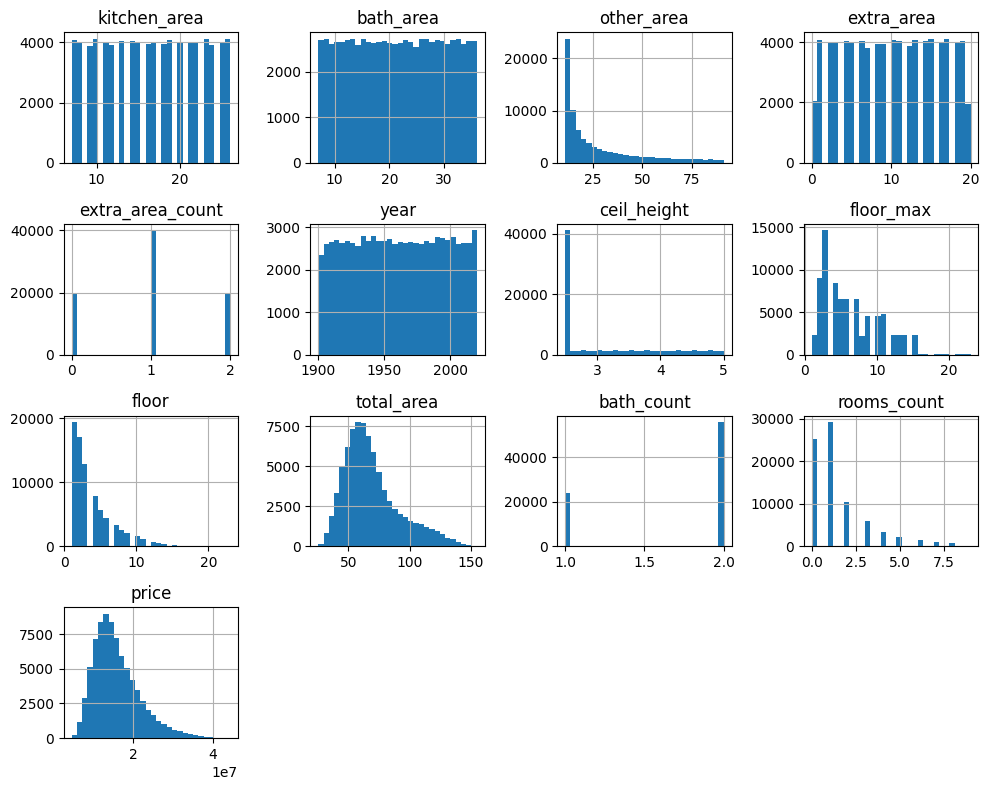

In [ ]:
import matplotlib.pyplot as plt

num_cols=train_df.select_dtypes(include=['int64','float64']).columns.drop('index')

train_df[num_cols].hist(bins=30, figsize=(10,8))
plt.title('гистограммы числовых признаков')
plt.tight_layout()

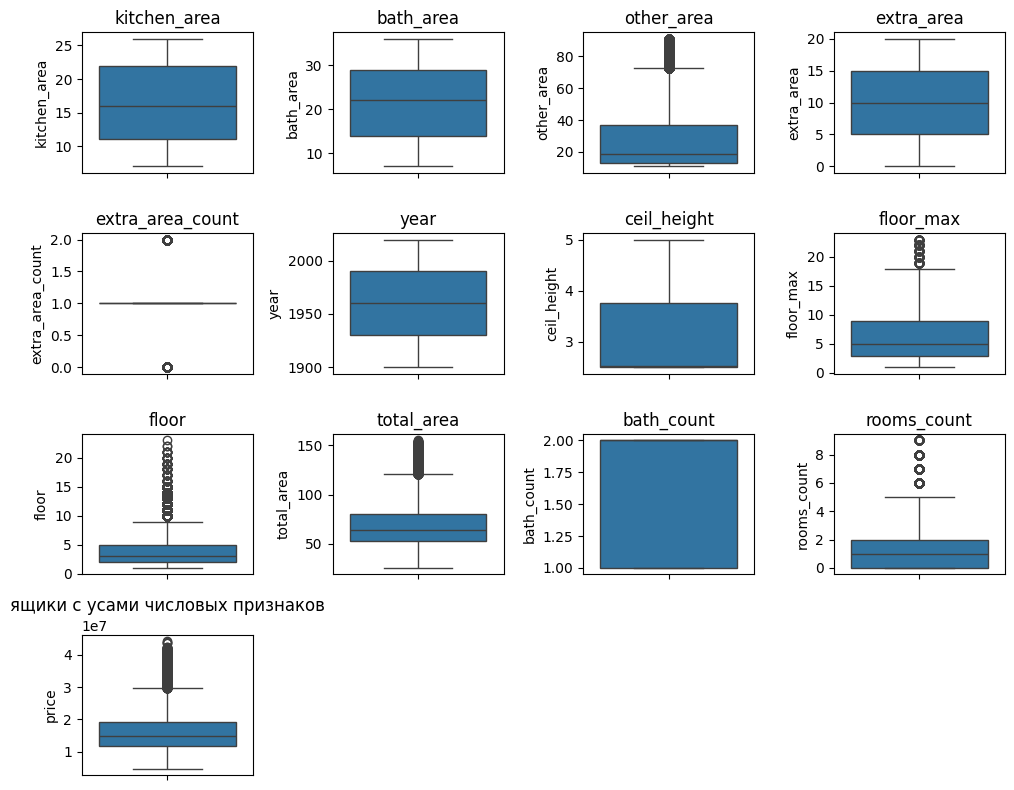

In [ ]:
import seaborn as sns

plt.figure(figsize=(10,8))

for i,col in enumerate(num_cols, 1):
  plt.subplot(4,4,i)
  sns.boxplot(data=train_df, y=col)
  plt.title(col)

plt.title('ящики с усами числовых признаков')
plt.tight_layout()

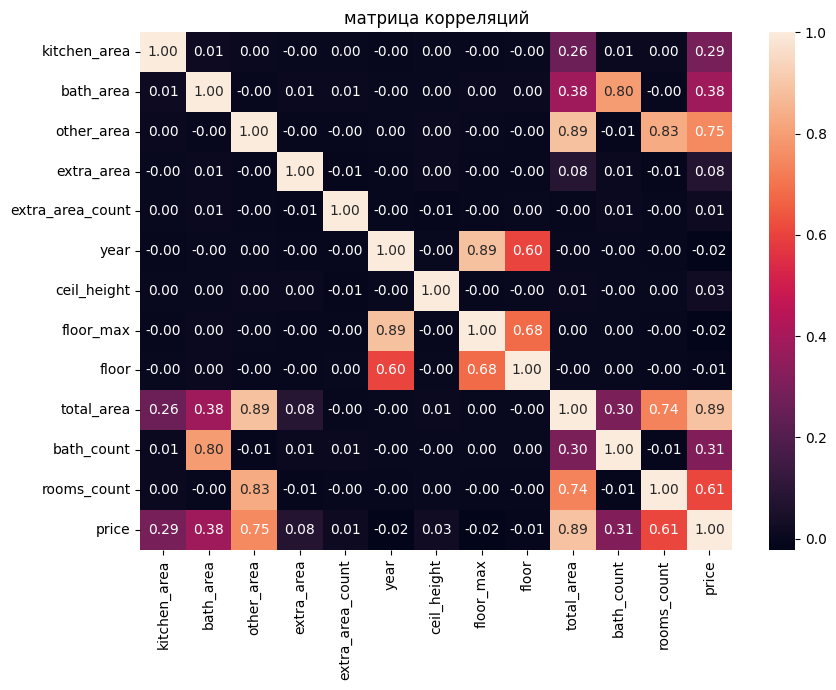

In [ ]:
corr_m=train_df[num_cols].corr()

plt.figure(figsize=(9,7))

sns.heatmap(corr_m, annot=True, fmt='.2f')
plt.title('матрица корреляций')

plt.tight_layout()

In [ ]:
# новые признаки

train_df['kitchen_ratio']=train_df['kitchen_area']/(train_df['total_area']+1)
val_df['kitchen_ratio']=val_df['kitchen_area']/(val_df['total_area']+1)
test_df['kitchen_ratio']=test_df['kitchen_area']/(test_df['total_area']+1)

train_df['bath_ratio']=train_df['bath_area']/(train_df['total_area']+1)
val_df['bath_ratio']=val_df['bath_area']/(val_df['total_area']+1)
test_df['bath_ratio']=test_df['bath_area']/(test_df['total_area']+1)

train_df['other_ratio']=train_df['other_area']/(train_df['total_area']+1)
val_df['other_ratio']=val_df['other_area']/(val_df['total_area']+1)
test_df['other_ratio']=test_df['other_area']/(test_df['total_area']+1)

train_df['area_per_room']=train_df['total_area']/(train_df['rooms_count']+1)
val_df['area_per_room']=val_df['total_area']/(val_df['rooms_count']+1)
test_df['area_per_room']=test_df['total_area']/(test_df['rooms_count']+1)

train_df['total_bath_area']=train_df['bath_area']*train_df['bath_count']
val_df['total_bath_area']=val_df['bath_area']*val_df['bath_count']
test_df['total_bath_area']=test_df['bath_area']*test_df['bath_count']

In [ ]:
for c in ['gas','hot_water','central_heating']:
  train_df[c]=train_df[c].map({'No':0,'Yes':1})
  val_df[c]=val_df[c].map({'No':0,'Yes':1})
  test_df[c]=test_df[c].map({'No':0,'Yes':1})

train_df['district_name']=train_df['district_name'].map({'Moskovskij':0,'Vyborgskij':1,'Petrogradskij':2,'Nevskij':3,
                                                         'Centralnyj':4,'Krasnoselskij':5,	'Kirovskij':6})
val_df['district_name']=val_df['district_name'].map({'Moskovskij':0,'Vyborgskij':1,'Petrogradskij':2,'Nevskij':3,
                                                         'Centralnyj':4,'Krasnoselskij':5,	'Kirovskij':6})
test_df['district_name']=test_df['district_name'].map({'Moskovskij':0,'Vyborgskij':1,'Petrogradskij':2,'Nevskij':3,
                                                         'Centralnyj':4,'Krasnoselskij':5,	'Kirovskij':6})

train_df['extra_area_type_name']=train_df['extra_area_type_name'].map({'balcony':0,'loggia':1})
val_df['extra_area_type_name']=val_df['extra_area_type_name'].map({'balcony':0,'loggia':1})
test_df['extra_area_type_name']=test_df['extra_area_type_name'].map({'balcony':0,'loggia':1})

In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 80000 entries, 75220 to 15795
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   index                 80000 non-null  int64  
 1   kitchen_area          80000 non-null  int64  
 2   bath_area             80000 non-null  int64  
 3   other_area            80000 non-null  float64
 4   gas                   80000 non-null  int64  
 5   hot_water             80000 non-null  int64  
 6   central_heating       80000 non-null  int64  
 7   extra_area            80000 non-null  int64  
 8   extra_area_count      80000 non-null  int64  
 9   year                  80000 non-null  int64  
 10  ceil_height           80000 non-null  float64
 11  floor_max             80000 non-null  int64  
 12  floor                 80000 non-null  int64  
 13  total_area            80000 non-null  float64
 14  bath_count            80000 non-null  int64  
 15  extra_area_type_name

In [ ]:
features=train_df.columns.drop(['index','price'])

X_train=train_df[features]
y_train=train_df['price']

X_val=val_df[features]
y_val=val_df['price']

X_test=test_df[features]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_val_scaled=scaler.transform(X_val)
X_test_scaled=scaler.transform(X_test)

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, mean_absolute_error, r2_score, mean_squared_error

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# функцию в scorer
rmse_scorer = make_scorer(rmse, greater_is_better=False)  # False тк меньше - лучше

model_lr=LinearRegression()
model_lr.fit(X_train_scaled, y_train)

y_val_pred1=model_lr.predict(X_val_scaled)

print('LinearRegression:\n')
print(f'RMSE: {rmse(y_val, y_val_pred1):.3f}')
print(f'MAE: {mean_absolute_error(y_val,y_val_pred1):.3f}')
print(f'R^2: {r2_score(y_val, y_val_pred1):.3f}')

LinearRegression:

RMSE: 2167291.105
MAE: 1781344.804
R^2: 0.856


In [ ]:
from xgboost import XGBRegressor

model_xgb=XGBRegressor(random_state=42, n_jobs=-1)

param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_random = RandomizedSearchCV(model_xgb,param_grid_xgb,n_iter=50,cv=5,scoring=rmse_scorer,n_jobs=-1,verbose=1)

xgb_random.fit(X_train, y_train)

print(f'лучшие параметры: {xgb_random.best_params_}')
print(f'лучший RMSE на кросс-валидации: {-xgb_random.best_score_:.3f}')

best_model_xgb = xgb_random.best_estimator_

y_val_pred2 = best_model_xgb.predict(X_val)

print('XGBoost:\n')
print(f'RMSE: {rmse(y_val, y_val_pred2):.3f}')
print(f'MAE: {mean_absolute_error(y_val, y_val_pred2):.3f}')
print(f'R^2: {r2_score(y_val, y_val_pred2):.3f}')

Fitting 5 folds for each of 50 candidates, totalling 250 fits
лучшие параметры: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
лучший RMSE на кросс-валидации: 191014.945
XGBoost:

RMSE: 186597.540
MAE: 150241.453
R^2: 0.999


In [ ]:
import torch
from torch.nn import Sequential, Linear, Dropout, BatchNorm1d, ReLU, Module, L1Loss
from torch.utils.data import TensorDataset, DataLoader
from torch import optim
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

# нормируем целевую переменную (цены)
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1))
y_val_scaled = y_scaler.transform(y_val.values.reshape(-1, 1))

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

In [ ]:
from torch.nn import Module, L1Loss

class RegressionNN(Module):
  def __init__(self, n_features):
    super().__init__()
    self.net=Sequential(
        Linear(n_features, 256),
        BatchNorm1d(256),
        ReLU(),
        Dropout(0.2),

        Linear(256,128),
        BatchNorm1d(128),
        ReLU(),
        Dropout(0.2),

        Linear(128, 64),
        ReLU(),

        Linear(64,1)
    )
  def forward(self,x):
    return self.net(x)


device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_nn=RegressionNN(X_train_scaled.shape[1]).to(device)
loss_f =L1Loss()
optimizer=optim.Adam(model_nn.parameters(), lr=0.001)
scheduler=optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

def train_model(model):
  best_val_loss = float('inf')
  for epoch in range(200):
    model.train()
    train_loss=0
    for X_batch, y_batch in train_loader:
      X_batch, y_batch= X_batch.to(device), y_batch.to(device)
      y_pred=model(X_batch)
      loss=loss_f(y_pred, y_batch)
      train_loss+=loss.item()

      loss.backward()
      optimizer.step()
      optimizer.zero_grad()

    model.eval()
    val_loss=0
    with torch.no_grad():
      for X_batch, y_batch in val_loader:
        X_batch, y_batch= X_batch.to(device), y_batch.to(device)
        y_pred=model(X_batch)
        loss=loss_f(y_pred, y_batch)
        val_loss+=loss.item()

    scheduler.step(val_loss)

    if val_loss < best_val_loss:
      best_val_loss = val_loss
      torch.save(model_nn.state_dict(), 'best_nn_model.pth')

    if (epoch+1)%10==0:
      print(f'эпоха {epoch+1}: train loss = {train_loss/len(train_loader):.2f}, val_loss = {val_loss/len(val_loader):.2f}')

  model.load_state_dict(torch.load('best_nn_model.pth'))
  return model

model= train_model(model_nn)

эпоха 10: train loss = 0.13, val_loss = 0.06
эпоха 20: train loss = 0.09, val_loss = 0.05
эпоха 30: train loss = 0.08, val_loss = 0.07
эпоха 40: train loss = 0.08, val_loss = 0.07
эпоха 50: train loss = 0.08, val_loss = 0.07
эпоха 60: train loss = 0.08, val_loss = 0.09
эпоха 70: train loss = 0.08, val_loss = 0.07
эпоха 80: train loss = 0.08, val_loss = 0.07
эпоха 90: train loss = 0.07, val_loss = 0.08
эпоха 100: train loss = 0.08, val_loss = 0.08
эпоха 110: train loss = 0.07, val_loss = 0.07
эпоха 120: train loss = 0.07, val_loss = 0.07
эпоха 130: train loss = 0.08, val_loss = 0.08
эпоха 140: train loss = 0.08, val_loss = 0.07
эпоха 150: train loss = 0.08, val_loss = 0.07
эпоха 160: train loss = 0.08, val_loss = 0.07
эпоха 170: train loss = 0.08, val_loss = 0.07
эпоха 180: train loss = 0.08, val_loss = 0.07
эпоха 190: train loss = 0.08, val_loss = 0.08
эпоха 200: train loss = 0.08, val_loss = 0.08


In [ ]:
model.eval()
with torch.no_grad():
    y_val_pred_scaled = model(X_val_tensor.to(device)).cpu().numpy()

#обратное масштабирование цен
y_val_pred = y_scaler.inverse_transform(y_val_pred_scaled)

print(f'MAE: {mean_absolute_error(y_val, y_val_pred):.0f}')
print(f'RMSE: {rmse(y_val, y_val_pred):.0f}')
print(f'R²: {r2_score(y_val, y_val_pred):.4f}')

MAE: 245803
RMSE: 322042
R²: 0.9968
